# Project: Mental Health Treatment-Seeking Prediction — Michael Steven Lamprea Vera & Jeyson Carmona Bedoya

**Dataset:** OSMI Mental Health in Tech Survey  
**Objective:** Predict whether a person seeks mental health treatment (`treatment` → `Target`).  
**Project pipeline:** Load → Cleaning → EDA → Feature Selection → Modeling → Evaluation with and without PCA.


https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey

## 1. Installing Dependencies

In [ ]:
!pip install -q category_encoders skrebate boruta matplotlib seaborn scikit-learn pandas numpy kagglehub


## 2. Importing Required Libraries

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2, RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

warnings.filterwarnings('ignore')
sns.set_theme(style='ticks')

## 3. Loading the Dataset

mental-health-in-tech-survey obtained from Kaggle: https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download('osmi/mental-health-in-tech-survey')
csv_path = os.path.join(dataset_path, 'survey.csv')

data = pd.read_csv(csv_path)
print(f'Dimensions: {data.shape}')
print(f'Columns: {list(data.columns)}')
data.head()


Using Colab cache for faster access to the 'mental-health-in-tech-survey' dataset.
Dimensiones: (1259, 27)
Columnas: ['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## 4. Data Cleaning

Since data collection allowed free-text entry in several categories, the following corrections are applied:

- **Columns:** normalized to lowercase with no spaces.
- **Gender:** text variants are consolidated into three categories: `male`, `female`, `other`. This is because several entries contain inconsistent/free-text values such as `m`, `uwu`, `F`, `im shay`, `im gay`.
- **Age:** records outside the valid range (18–65 years) are filtered out.


In [ ]:
# Normalize column names
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Normalize gender
data['gender'] = data['gender'].str.lower().str.strip()

male_values = [
    'male', 'm', 'male-ish', 'maile', 'mal', 'male (cis)', 'make', 'male ',
    'man', 'msle', 'mail', 'malr', 'cis man', 'cis male'
]
female_values = [
    'cis female', 'f', 'female', 'woman', 'femake', 'female ',
    'cis-female/femme', 'female (cis)', 'femail'
]

def map_gender(g):
    if g in male_values:
        return 'male'
    elif g in female_values:
        return 'female'
    else:
        return 'other'

data['gender'] = data['gender'].apply(map_gender)

# Filter valid ages
data = data[(data['age'] >= 18) & (data['age'] <= 65)]

print('Gender distribution:')
print(data['gender'].value_counts())
print(f'\nRecords after cleaning: {data.shape[0]}')


Distribución de género:
gender
male      986
female    246
other      18
Name: count, dtype: int64

Registros después de limpieza: 1250


## 5. Exploratory Data Analysis (EDA)

The dataset structure, the distribution of the future target, and null values are examined.


In [ ]:
for column in data.select_dtypes(include='object').columns:
    if column not in ['timestamp', 'comments']:
        print(f'\nDistribution of column: {column}')
        print(data[column].value_counts())
        #print(data[column].value_counts(normalize=True).round(3))



Distribución de la columna: gender
gender
male      986
female    246
other      18
Name: count, dtype: int64

Distribución de la columna: country
country
United States             745
United Kingdom            184
Canada                     72
Germany                    45
Netherlands                27
Ireland                    27
Australia                  21
France                     13
India                      10
New Zealand                 8
Italy                       7
Switzerland                 7
Poland                      7
Sweden                      7
Brazil                      6
South Africa                6
Belgium                     6
Israel                      5
Singapore                   4
Bulgaria                    4
Russia                      3
Mexico                      3
Finland                     3
Austria                     3
Portugal                    2
Colombia                    2
Denmark                     2
Croatia                     2
Gree

In [ ]:
print('General information')
print(data.info())
print('\nDescriptive statistics')
print(data.describe())


Información general
<class 'pandas.core.frame.DataFrame'>
Index: 1250 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   timestamp                  1250 non-null   object
 1   age                        1250 non-null   int64 
 2   gender                     1250 non-null   object
 3   country                    1250 non-null   object
 4   state                      737 non-null    object
 5   self_employed              1232 non-null   object
 6   family_history             1250 non-null   object
 7   treatment                  1250 non-null   object
 8   work_interfere             988 non-null    object
 9   no_employees               1250 non-null   object
 10  remote_work                1250 non-null   object
 11  tech_company               1250 non-null   object
 12  benefits                   1250 non-null   object
 13  care_options               1250 non-null   objec

In [ ]:
print('Target distribution (treatment)')
print(data['treatment'].value_counts())
print(data['treatment'].value_counts(normalize=True).round(3))

print('\nDistribution of work_interfere')
print(data['work_interfere'].value_counts())

print('\nNull values per column')
print(data.isnull().sum())


Distribución del target (treatment)
treatment
Yes    631
No     619
Name: count, dtype: int64
treatment
Yes    0.505
No     0.495
Name: proportion, dtype: float64

Distribución de work_interfere
work_interfere
Sometimes    464
Never        211
Rarely       173
Often        140
Name: count, dtype: int64

Valores nulos por columna 
timestamp                       0
age                             0
gender                          0
country                         0
state                         513
self_employed                  18
family_history                  0
treatment                       0
work_interfere                262
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequenc

## 6. Variable Encoding and Building `df_EDA`

The target variable is renamed to `Target` (0 = Does not seek treatment, 1 = Seeks treatment) and `LabelEncoder` is applied to all categorical variables to enable numerical analysis.


In [ ]:
# Removing null values; since these are categorical variables we use the mode

df_EDA = data.copy()

# Fill 'state' with a common value (e.g., the mode)
# The mode is the most frequently occurring value
most_frequent_state = df_EDA['state'].mode()[0]
df_EDA['state'].fillna(most_frequent_state, inplace=True)

# Fill 'self_employed' and 'work_interfere' with the mode
for col in ['self_employed', 'work_interfere']:
    if df_EDA[col].isnull().any():
        most_frequent_value = df_EDA[col].mode()[0]
        df_EDA[col].fillna(most_frequent_value, inplace=True)

# Fill 'comments' with an empty string or 'No Comment'
df_EDA['comments'].fillna('No Comment', inplace=True)

print('\nNull values after filling:')
print(df_EDA.isnull().sum()[df_EDA.isnull().sum() > 0])

# Show info to verify the changes
print('\nInfo for data_filled after filling:')
df_EDA.info()



Valores nulos después de rellenar:
Series([], dtype: int64)

Información de data_filled después de rellenar:
<class 'pandas.core.frame.DataFrame'>
Index: 1250 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   timestamp                  1250 non-null   object
 1   age                        1250 non-null   int64 
 2   gender                     1250 non-null   object
 3   country                    1250 non-null   object
 4   state                      1250 non-null   object
 5   self_employed              1250 non-null   object
 6   family_history             1250 non-null   object
 7   treatment                  1250 non-null   object
 8   work_interfere             1250 non-null   object
 9   no_employees               1250 non-null   object
 10  remote_work                1250 non-null   object
 11  tech_company               1250 non-null   object
 12  benefits     

LabelEncoder allows us to convert categorical variables into numerical ones.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- Start of code to ensure df_EDA is clean and NaNs are filled (from kKMsKOSAZT53) ---
# Removing null values; since these are categorical variables we use the mode
df_EDA = data.copy()
# Fill 'state' with a common value (e.g., the mode)
# The mode is the most frequently occurring value
most_frequent_state = df_EDA['state'].mode()[0]
df_EDA['state'].fillna(most_frequent_state, inplace=True)
# Fill 'self_employed' and 'work_interfere' with the mode
for col in ['self_employed', 'work_interfere']:
    if df_EDA[col].isnull().any():
        most_frequent_value = df_EDA[col].mode()[0]
        df_EDA[col].fillna(most_frequent_value, inplace=True)
# Fill 'comments' with an empty string or 'No Comment'
df_EDA['comments'].fillna('No Comment', inplace=True)
# --- End of data filling code ---

# Rename and encode the target
df_EDA = df_EDA.rename(columns={'treatment': 'Target'})
df_EDA['Target'] = df_EDA['Target'].map({'No': 0, 'Yes': 1})

# Label Encoding for categorical variables, excluding 'comments', 'country', and 'timestamp'
# Store the encoders so the mappings can be inspected
label_encoders = {}

cols_to_exclude = ['comments', 'country', 'timestamp']
cols_categoricas = [col for col in df_EDA.select_dtypes(include='object').columns if col not in cols_to_exclude]

for col in cols_categoricas:
    encoder = LabelEncoder()
    df_EDA[col] = encoder.fit_transform(df_EDA[col])
    label_encoders[col] = encoder # Save the encoder

# Convert 'timestamp' to numeric format (Unix timestamp)
df_EDA['timestamp'] = pd.to_datetime(df_EDA['timestamp']).astype(np.int64) // 10**9

# Move Target to the end
cols = [c for c in df_EDA.columns if c != 'Target'] + ['Target']
df_EDA = df_EDA[cols]

print(f'df_EDA dimensions: {df_EDA.shape}')
print('\nDescriptive statistics:')
print(df_EDA.describe())
df_EDA.info()


Dimensiones de df_EDA: (1250, 27)

Descriptive statistics:
          timestamp          age       gender       state  self_employed  \
count  1.250000e+03  1250.000000  1250.000000  1250.00000    1250.000000   
mean   1.410313e+09    32.044800     0.817600    13.59200       0.113600   
std    4.625913e+06     7.203076     0.421987    14.70516       0.317452   
min    1.409139e+09    18.000000     0.000000     0.00000       0.000000   
25%    1.409150e+09    27.000000     1.000000     2.00000       0.000000   
50%    1.409192e+09    31.000000     1.000000     2.00000       0.000000   
75%    1.409267e+09    36.000000     1.000000    28.00000       0.000000   
max    1.454368e+09    65.000000     2.000000    44.00000       1.000000   

       family_history  work_interfere  no_employees  remote_work  \
count     1250.000000     1250.000000   1250.000000  1250.000000   
mean         0.390400        2.131200      2.791200     0.296000   
std          0.488035        1.162699      1.737014 

## 7. Visualizations

### 7.1 Correlation Matrix

The correlation between all numerical features (excluding the target) is analyzed.


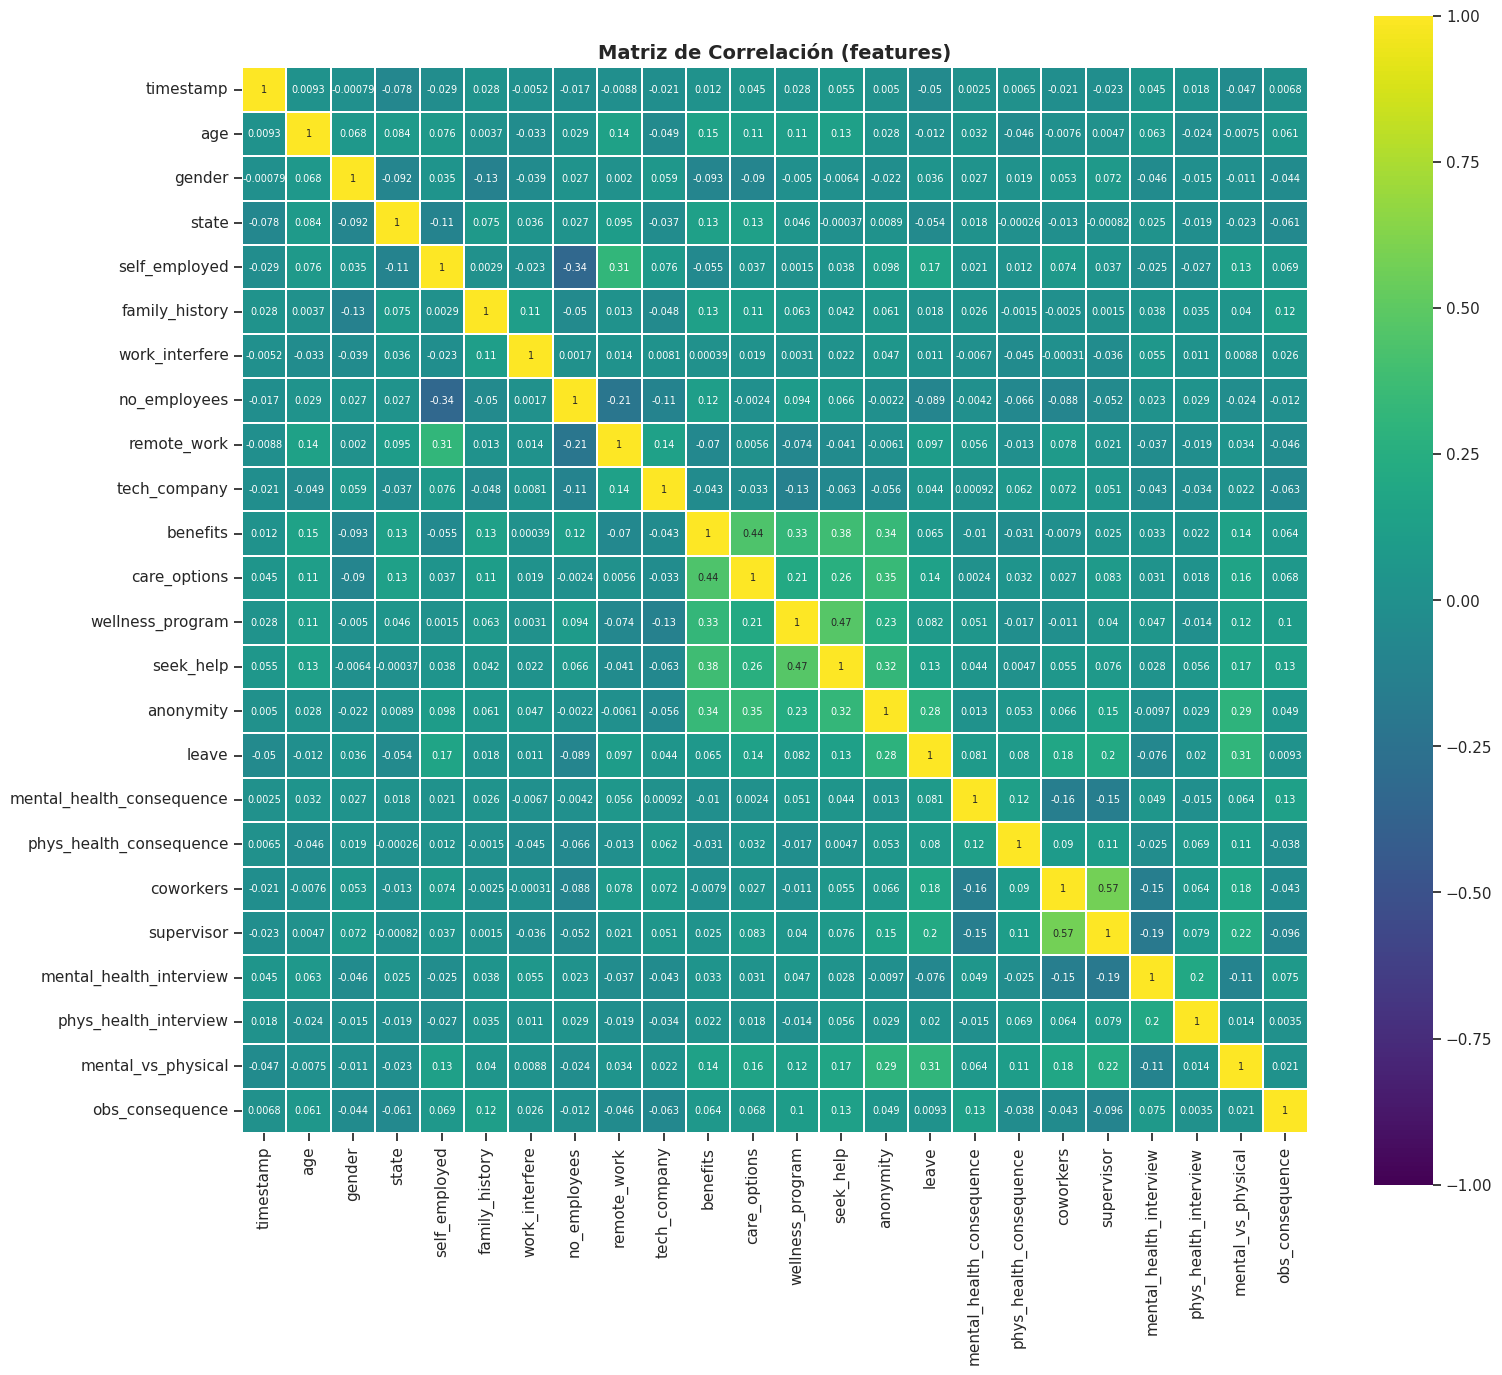

In [ ]:
df_num = df_EDA.drop(columns=['Target']).select_dtypes(include='number')
corr = df_num.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    cmap='viridis',
    vmax=1.0, vmin=-1.0,
    linewidths=0.1,
    annot=True,
    annot_kws={'size': 7},
    square=True
)
plt.title('Correlation Matrix (features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Conclusions we can draw from the correlation map:

- `benefits` and `care_options` have a correlation of 0.44, making them one of the most correlated pairs in the entire dataset. This makes sense: companies that offer health benefits also tend to offer care options. It might be worth considering keeping only one of the two.


- `coworkers` and `supervisor` show a correlation of 0.57 — both measure openness to talk about mental health at work, which makes them somewhat redundant with each other; removing one of these variables could be considered.


- `wellness_program` and `seek_help` have a correlation of 0.47 — logical, since wellness programs are usually accompanied by resources for seeking help.

### 7.2 Feature Correlation with the Target (Spearman)

The 10 variables with the highest correlation with `Target` are identified.


In [ ]:
cor = df_EDA.corr(method='spearman', numeric_only=True)['Target'].abs().sort_values(ascending=False)
top_features = cor[1:11].index.tolist()

print('Top 10 features most correlated with Target:')
print(cor[1:11])


Top 10 features más correlacionadas con Target:
family_history             0.376067
care_options               0.232769
benefits                   0.224420
gender                     0.157417
obs_consequence            0.151016
anonymity                  0.144256
mental_health_interview    0.094681
wellness_program           0.093025
seek_help                  0.086911
work_interfere             0.078096
Name: Target, dtype: float64


### 7.3 Pairplot by Class

Scatterplot matrix for the top features, distinguishing whether the person seeks treatment (Target=1) or not (Target=0).


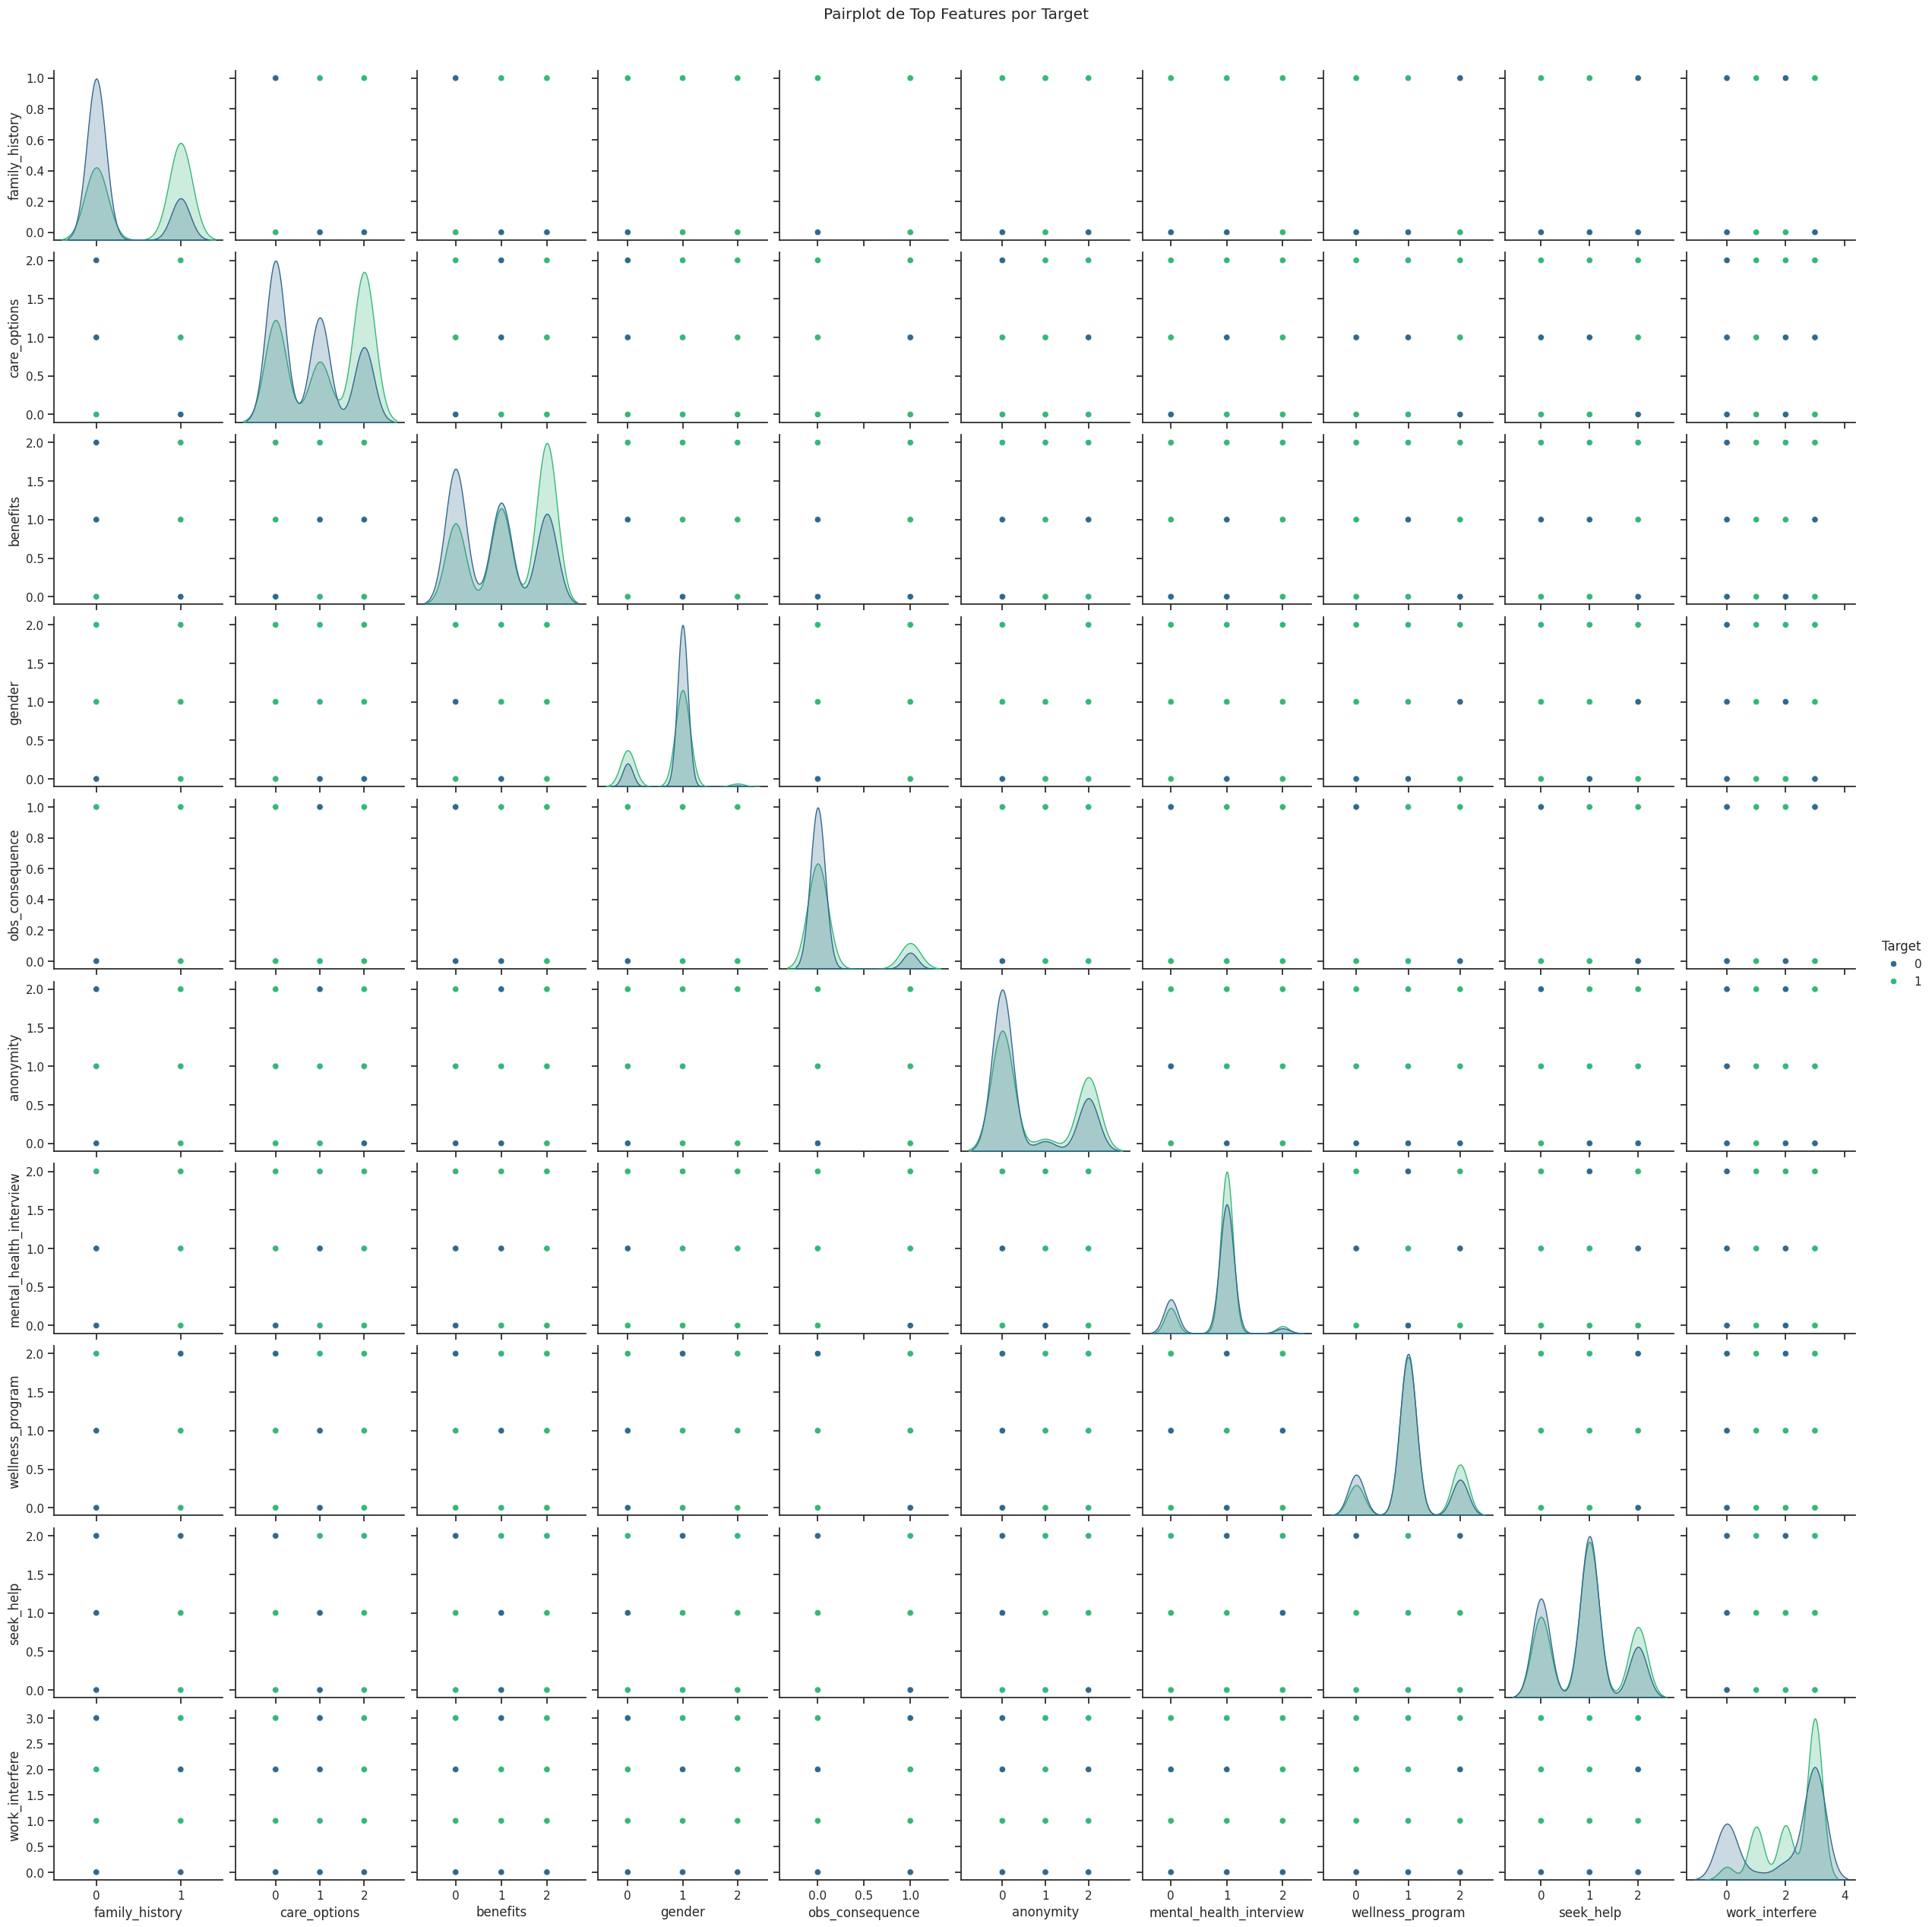

In [ ]:
sns.pairplot(df_EDA[top_features + ['Target']], hue='Target', palette='viridis')
plt.suptitle('Pairplot of Top Features by Target', y=1.02)
plt.show()


### 7.4 Box Plots of Key Variables

The distribution of the most relevant variables is compared based on whether the individual seeks treatment or not.


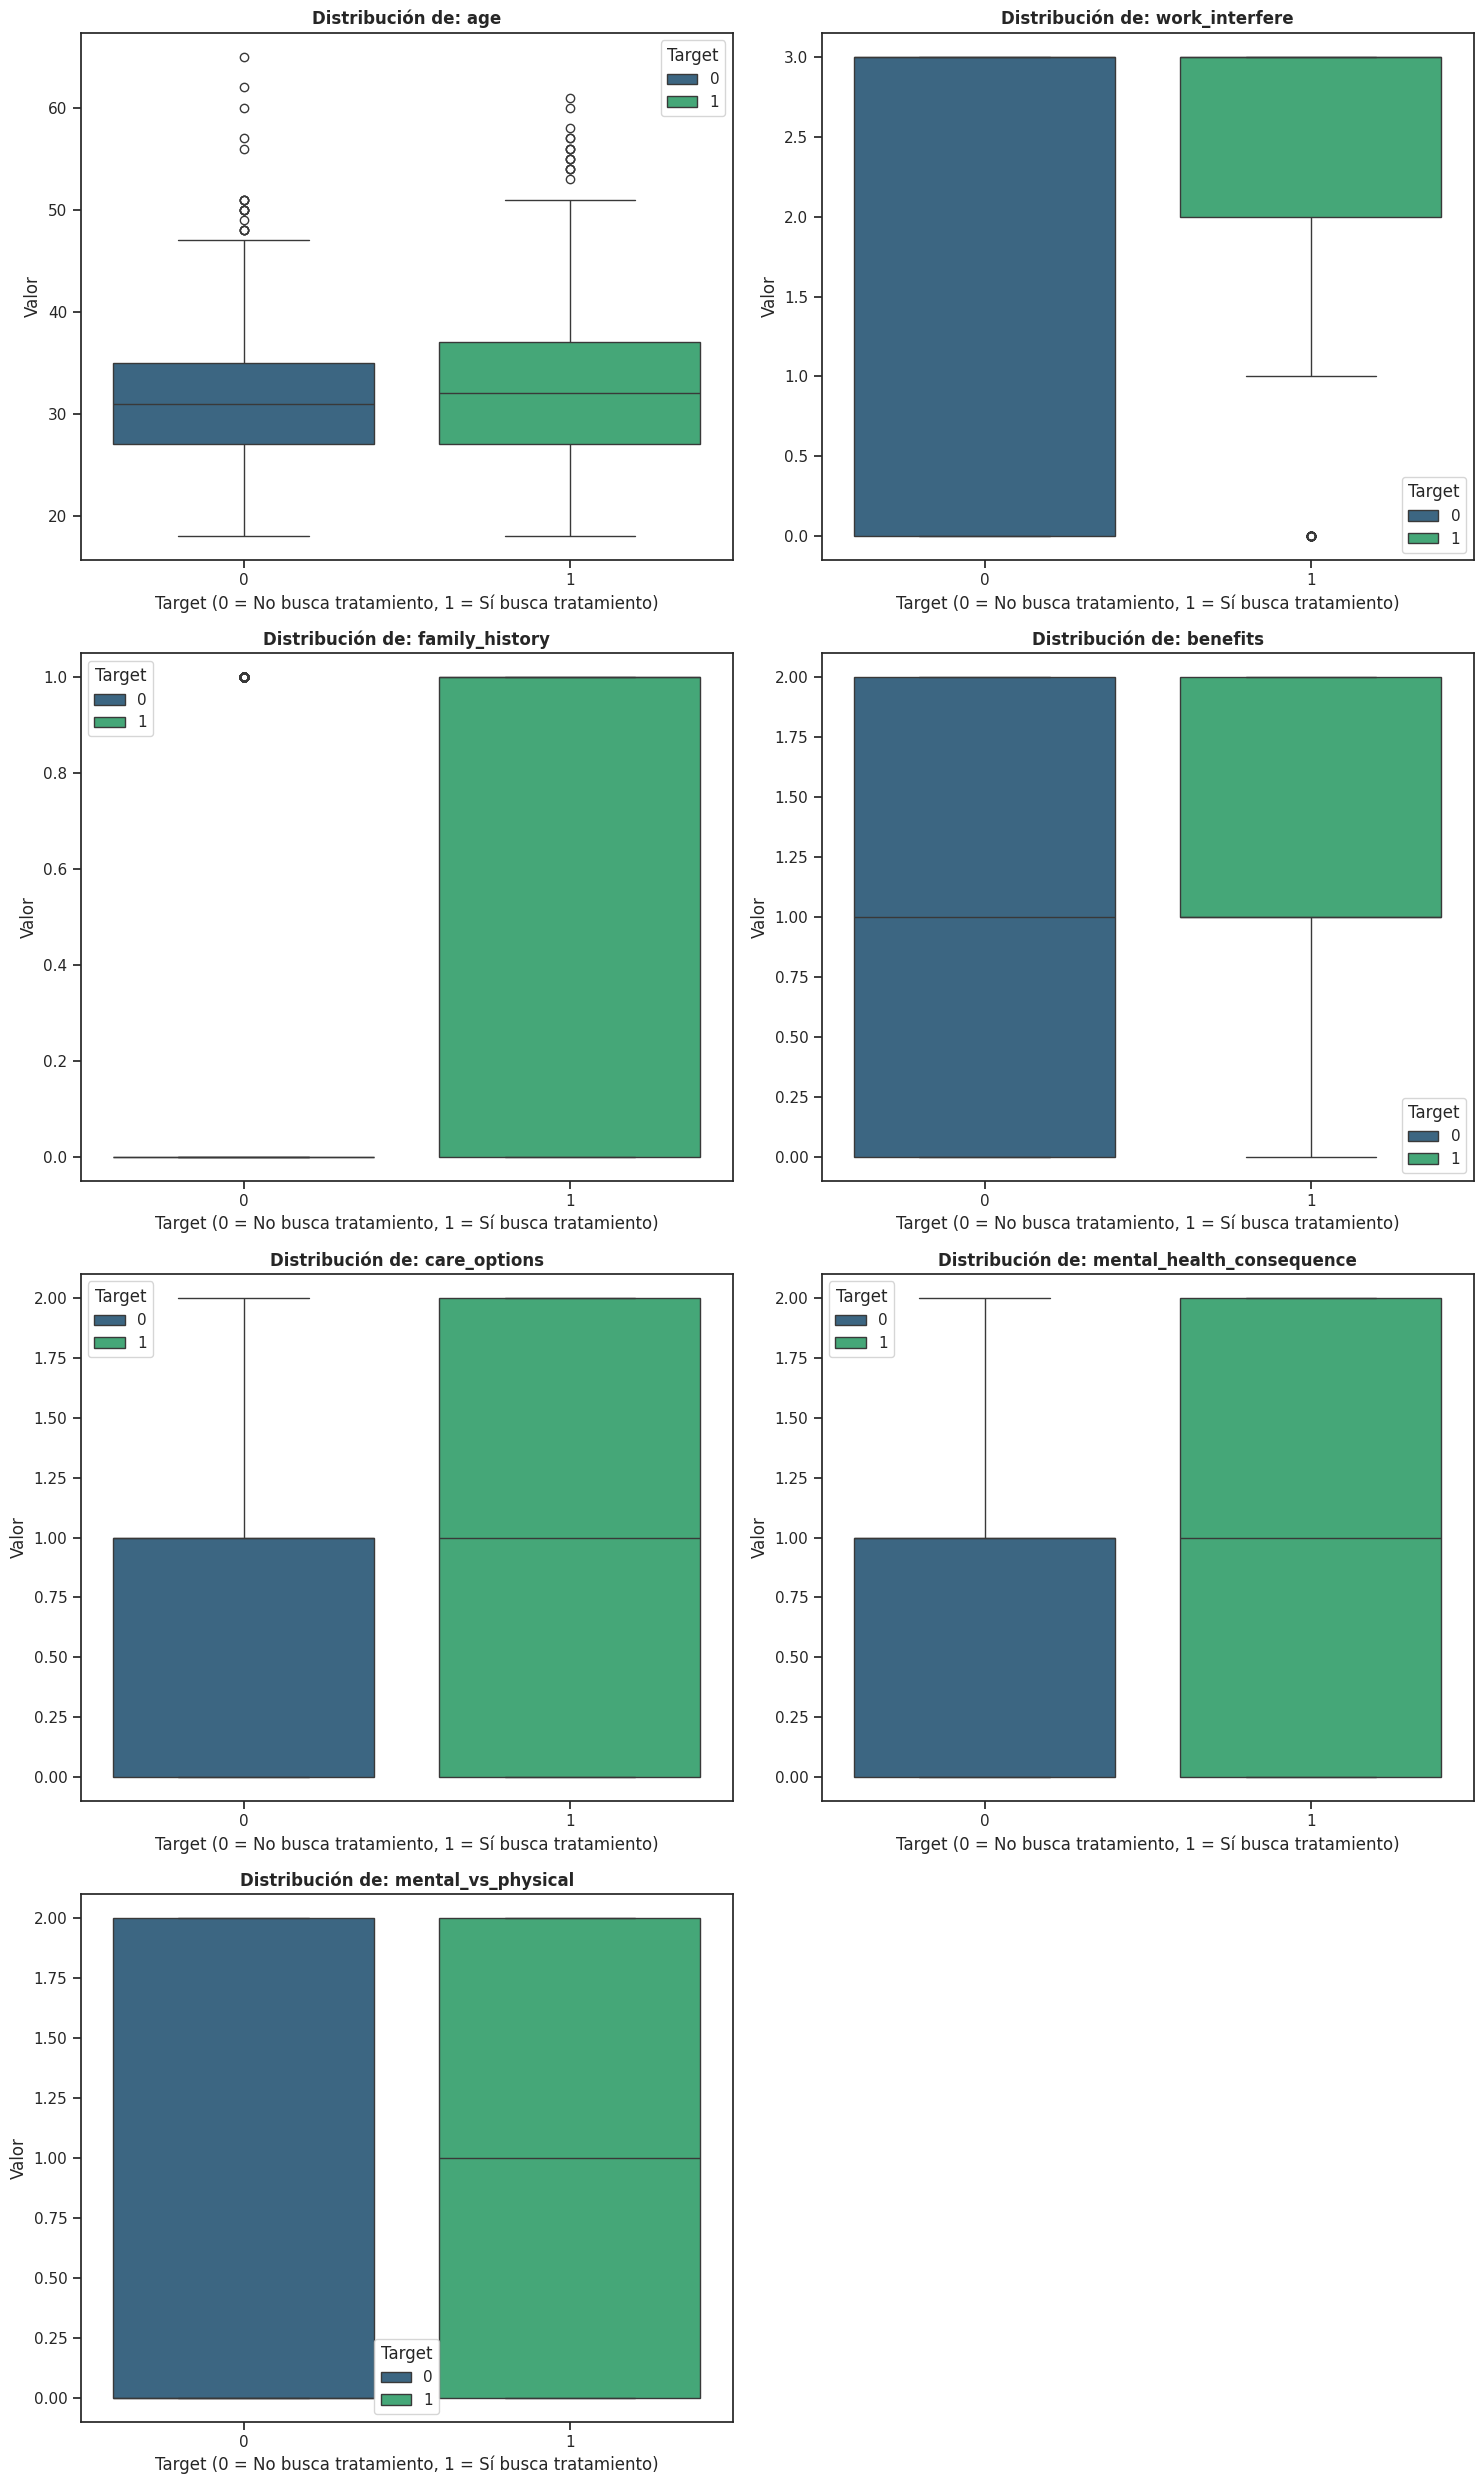

In [ ]:
columnas_estudio = [
    'age', 'work_interfere', 'family_history',
    'benefits', 'care_options', 'mental_health_consequence', 'mental_vs_physical'
]

fig, axes = plt.subplots(4, 2, figsize=(15, 25))
axes = axes.flatten()

for i, col in enumerate(columnas_estudio):
    sns.boxplot(
        data=df_EDA,
        x='Target', y=col,
        hue='Target',
        palette='viridis',
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Target (0 = Does not seek treatment, 1 = Seeks treatment)')
    axes[i].set_ylabel('Value')

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()


Not all of our categories contribute equally to predicting whether someone seeks treatment. This section aims to answer the question: which variables actually matter to the model? To do this, we will use 4 different methods, each with a different underlying logic, and then compare them.

Chi-Square (statistical dependence), RFE (recursive feature elimination), Mutual Information (non-linear relationships), and SMLR (cross-validated coefficients)

## 9. Train/Test Split

`stratify=y` is used to preserve the class proportions in both sets. Scaling is applied only to the continuous numerical variable (`age`).


In [ ]:
X = df_EDA.drop(columns=['Target'])
y = df_EDA['Target']

print('Target distribution:')
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale only the continuous numerical variable
cols_numericas = ['age']
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test[cols_numericas]  = scaler.transform(X_test[cols_numericas])

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')


Distribución del target:
Target
1    631
0    619
Name: count, dtype: int64
Target
1    0.505
0    0.495
Name: proportion, dtype: float64

Train: (1000, 26) | Test: (250, 26)


## 10. Models and Evaluation Functions

8 classifiers and helper functions to evaluate and plot results are defined.


In [ ]:
models = {
    'DTC':  DecisionTreeClassifier(random_state=0),
    'RF':   RandomForestClassifier(random_state=0),
    'ETC':  ExtraTreesClassifier(random_state=0),
    'GB':   GradientBoostingClassifier(random_state=0),
    'KNN':  KNeighborsClassifier(),
    'SGDC': SGDClassifier(random_state=0),
    'LR':   LogisticRegression(random_state=0, max_iter=5000, class_weight='balanced'),
    'MLP':  MLPClassifier(random_state=0, max_iter=500),
    'SVC':  SVC(random_state=0, probability=True, class_weight='balanced')
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluar_modelo(nombre, y_true, y_pred):
    """Computes and returns the classification metrics for a model."""
    return {
        'Model':      nombre,
        'Accuracy':   accuracy_score(y_true, y_pred),
        'Precision':  precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':     recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 Score':   f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

def graficar_confusion(y_true, y_pred, titulo):
    """Plots the confusion matrix with descriptive labels."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Treatment', 'Seeks Treatment'],
        yticklabels=['No Treatment', 'Seeks Treatment']
    )
    plt.title(titulo, fontweight='bold')
    plt.xlabel('Prediction')
    plt.ylabel('Actual Value')
    plt.tight_layout()
    plt.show()


## 11. Hyperparameter Optimization with GridSearchCV


Stratified cross-validation (5-fold) is used to search for the best hyperparameters for each model, optimizing the F1-score. This approach was chosen based on the following number of training combinations:

DTC: 4 × 2 × 2 × 1 = 16

RF: 2 × 3 × 2 × 2 × 1 × 1 = 24

ETC: 2 × 2 × 2 × 1 × 1 = 8

GB: 2 × 2 × 2 = 8

KNN: 3 × 1 × 1 = 3

SGDC: 1 × 1 × 2 = 2

LR: 3 × 1 × 1 = 3

MLP: 2 × 1 × 1 × 2 × 1 = 4

for a total of 68 combinations.
In addition, we also use StratifiedKFold with 5 folds, which implicitly multiplies these 68 combinations, giving a total of 340 trainings overall.


In [ ]:
param_grids = {
    'DTC':  {'max_depth': [8, 12, 16, None], 'min_samples_split': [5, 10],
             'min_samples_leaf': [2, 4], 'criterion': ['gini']},
    'RF':   {'n_estimators': [200, 400], 'max_depth': [12, 18, None],
             'min_samples_split': [5, 10], 'min_samples_leaf': [2, 4],
             'max_features': ['sqrt'], 'class_weight': ['balanced']},
    'ETC':  {'n_estimators': [200, 400], 'max_depth': [12, None],
             'min_samples_leaf': [2, 4], 'criterion': ['gini'],
             'class_weight': ['balanced']},
    'GB':   {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]},
    'KNN':  {'n_neighbors': [7, 9, 11], 'weights': ['distance'], 'metric': ['manhattan']},
    'SGDC': {'loss': ['log_loss'], 'penalty': ['l2'], 'alpha': [0.001, 0.01]},
    'LR':   {'C': [0.1, 1, 10], 'solver': ['liblinear'], 'class_weight': ['balanced']},
    'MLP':  {'hidden_layer_sizes': [(50,), (100,)], 'activation': ['relu'],
             'solver': ['adam'], 'alpha': [0.0001, 0.001], 'learning_rate': ['adaptive']},
    'SVC': {'C': [1, 10], 'kernel': ['rbf'], 'gamma': ['scale']}
}

best_models = {}
print('Starting hyperparameter search... this may take a few minutes.\n')

# Identify non-numeric columns that are not suitable for direct modeling
non_numeric_cols = X_train.select_dtypes(include='object').columns.tolist()
if non_numeric_cols:
    print(f"Removing non-numeric columns from X_train and X_test for the GridSearch: {non_numeric_cols}\n")
    X_train_numeric = X_train.drop(columns=non_numeric_cols)
    X_test_numeric = X_test.drop(columns=non_numeric_cols)
else:
    X_train_numeric = X_train
    X_test_numeric = X_test

for name, model in models.items():
    print(f'Optimizing {name}...')
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv_strategy,
        scoring={
    'f1':       make_scorer(f1_score, average='weighted', zero_division=0),
    'accuracy': make_scorer(accuracy_score)
},
refit='f1',
    )
    gs.fit(X_train_numeric, y_train)
    best_models[name] = gs.best_estimator_
    print(f'  Best parameters: {gs.best_params_}')
    print(f'  Best F1 (CV):      {gs.best_score_:.4f}')

    # Retrieve the best accuracy score from cv_results
    best_idx = gs.best_index_
    best_accuracy_score = gs.cv_results_['mean_test_accuracy'][best_idx]
    print(f'  Best Accuracy (CV): {best_accuracy_score:.4f}\n')

print('Search complete!')


Iniciando búsqueda de hiperparámetros... esto puede tardar unos minutos.

Eliminando columnas no numéricas de X_train y X_test para el GridSearch: ['country', 'comments']

Optimizando DTC...
  Mejores parámetros: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10}
  Mejor F1 (CV):      0.6871
  Mejor Accuracy (CV): 0.6880

Optimizando RF...
  Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
  Mejor F1 (CV):      0.7399
  Mejor Accuracy (CV): 0.7400

Optimizando ETC...
  Mejores parámetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 400}
  Mejor F1 (CV):      0.7359
  Mejor Accuracy (CV): 0.7360

Optimizando GB...
  Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Mejor F1 (CV):      0.7369
  Mejor Accuracy (CV): 0.7370

Optimizando KNN...
  Mejore

## 12. Evaluation of Optimized Models (Without PCA)

The models with the best hyperparameters are evaluated on the original test set.


Resultados en Test Set (Sin PCA):


,Accuracy,Precision,Recall,F1 Score
GB,0.772,0.772032,0.772,0.772004
ETC,0.760,0.760328,0.760,0.759969
RF,0.752,0.752322,0.752,0.751968
DTC,0.708,0.711317,0.708,0.707086
KNN,0.532,0.532108,0.532,0.531978
SGDC,0.504,0.254016,0.504,0.337787
LR,0.504,0.254016,0.504,0.337787
MLP,0.496,0.246016,0.496,0.328898
SVC,0.496,0.246016,0.496,0.328898



Mejor modelo: GB
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       124
           1       0.78      0.77      0.77       126

    accuracy                           0.77       250
   macro avg       0.77      0.77      0.77       250
weighted avg       0.77      0.77      0.77       250



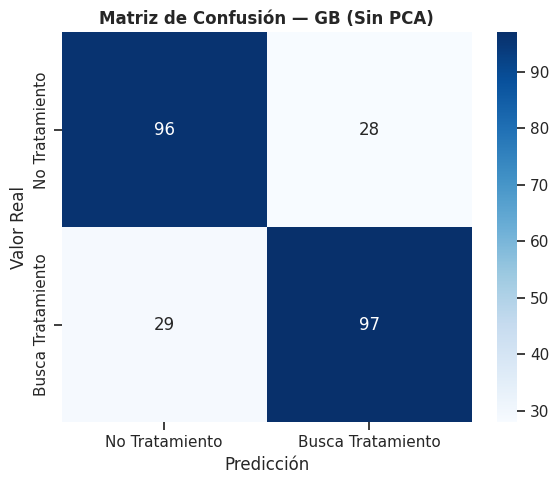

In [ ]:
results_test = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test_numeric)
    results_test[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1 Score':  f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }

df_results_test = pd.DataFrame.from_dict(results_test, orient='index')
print('Results on Test Set (Without PCA):')
display(df_results_test.sort_values('F1 Score', ascending=False))

# Report of the best model without PCA
best_name_no_pca = df_results_test['F1 Score'].idxmax()
y_pred_best = best_models[best_name_no_pca].predict(X_test_numeric)
print(f'\nBest model: {best_name_no_pca}')
print(classification_report(y_test, y_pred_best, zero_division=0))
graficar_confusion(y_test, y_pred_best, f'Confusion Matrix — {best_name_no_pca} (Without PCA)')


## 13. Dimensionality Reduction with PCA

PCA is applied, preserving 96% of the explained variance, on the already-scaled data.


In [ ]:
scaler_pca = StandardScaler()
X_train_sc = scaler_pca.fit_transform(X_train_numeric)
X_test_sc  = scaler_pca.transform(X_test_numeric)

pca = PCA(n_components=0.96)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'Original variables:  {X_train_sc.shape[1]}')
print(f'Components after PCA:  {X_train_pca.shape[1]}')
print(f'Explained variance:    {sum(pca.explained_variance_ratio_):.4f}')


Variables originales:  24
Componentes tras PCA:  22
Varianza explicada:    0.9626


## 14. Evaluation of Optimized Models (With PCA)

The best models are retrained on the PCA-reduced data and evaluated on the transformed test set.


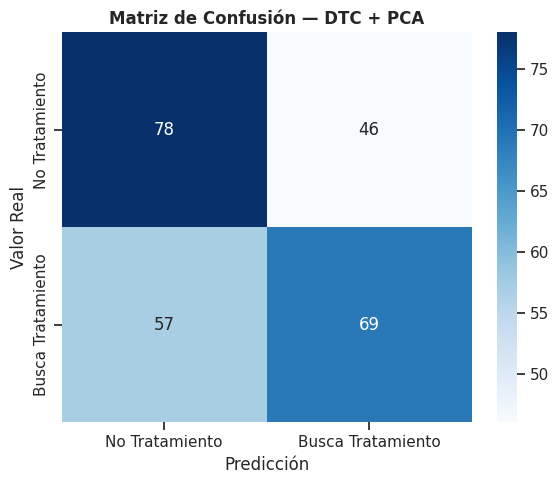

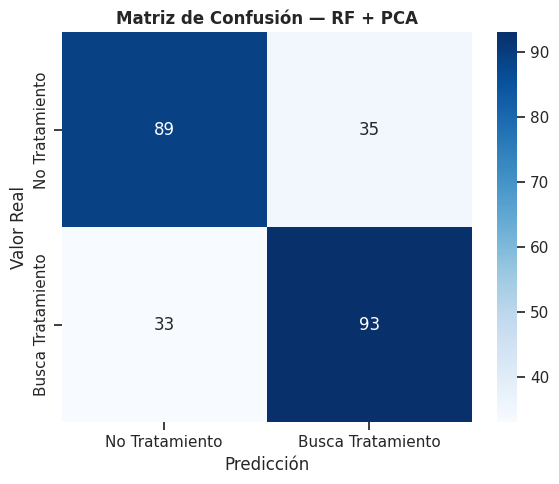

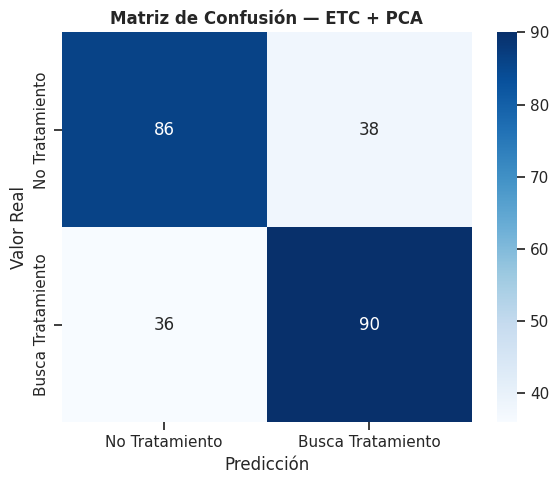

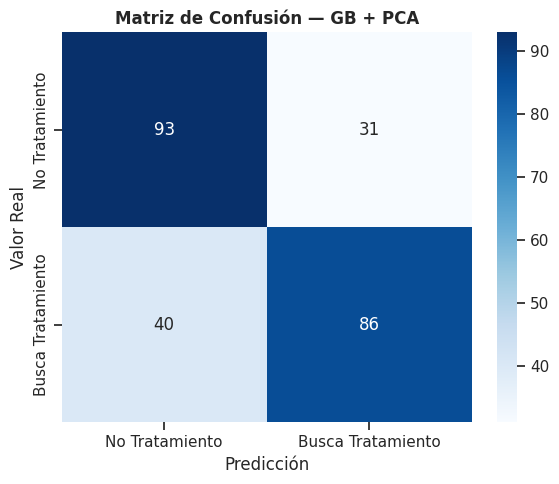

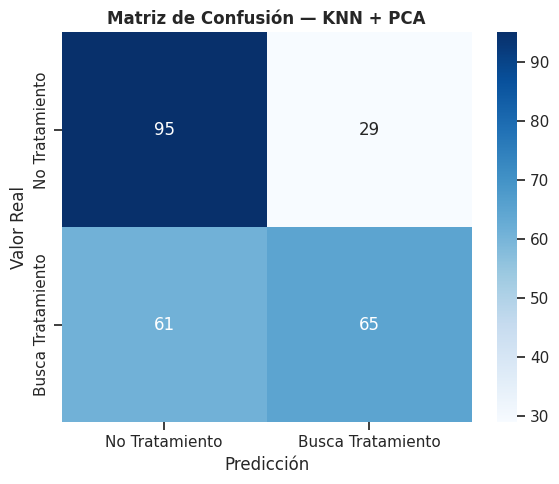

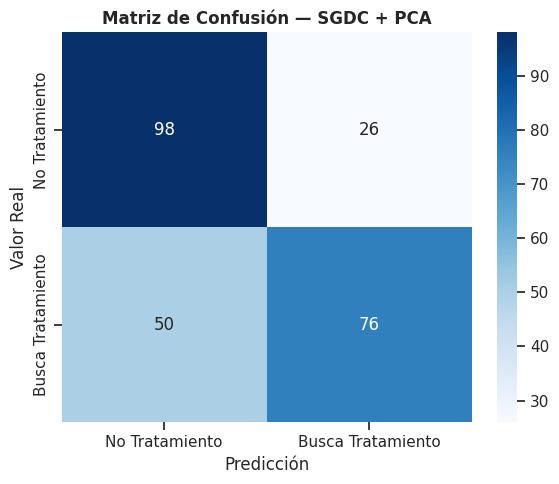

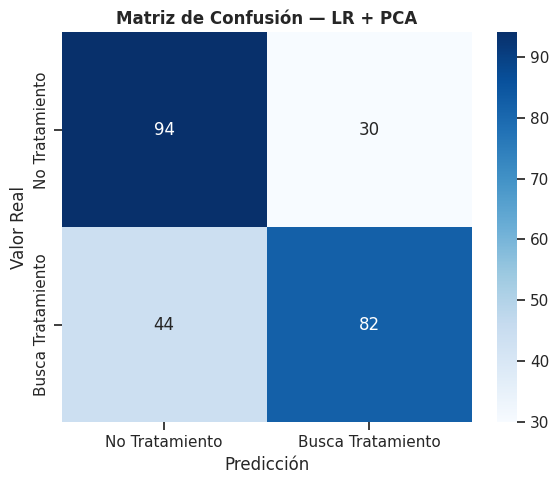

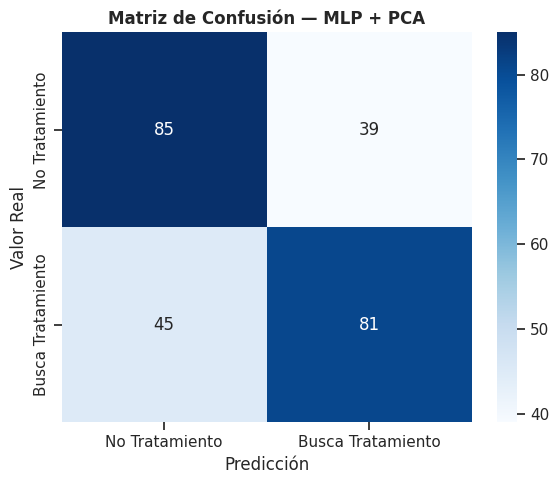

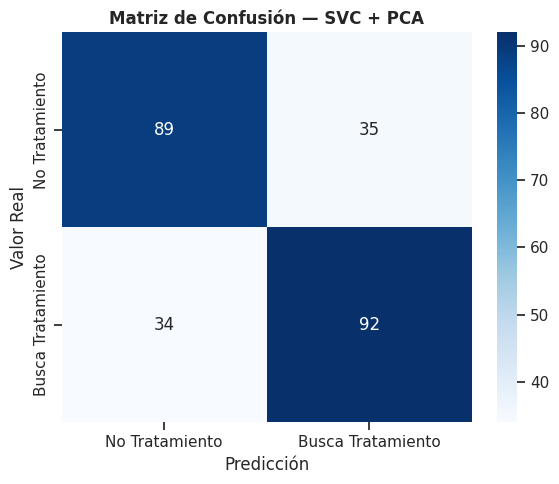

Resultados en Test Set (Con PCA):


,Accuracy,Precision,Recall,F1 Score
Modelo,,,,
RF + PCA,0.728,0.728024,0.728,0.727965
SVC + PCA,0.724,0.723997,0.724,0.723987
GB + PCA,0.716,0.717289,0.716,0.715714
ETC + PCA,0.704,0.704014,0.704,0.703962
LR + PCA,0.704,0.706855,0.704,0.703203
SGDC + PCA,0.696,0.703962,0.696,0.693412
MLP + PCA,0.664,0.664508,0.664,0.663871
KNN + PCA,0.640,0.650562,0.640,0.634390
DTC + PCA,0.588,0.588978,0.588,0.587347


In [ ]:
resultados_con_pca = []

for nombre, modelo in best_models.items():
    modelo.fit(X_train_pca, y_train)
    y_pred = modelo.predict(X_test_pca)
    resultados_con_pca.append(evaluar_modelo(f'{nombre} + PCA', y_test, y_pred))
    graficar_confusion(y_test, y_pred, f'Confusion Matrix — {nombre} + PCA')

df_con_pca = pd.DataFrame(resultados_con_pca).set_index('Model')
print('Results on Test Set (With PCA):')
display(df_con_pca.sort_values('F1 Score', ascending=False))


## 15. Comparison: Without PCA vs. With PCA

The F1-scores of each model are compared across both configurations to determine whether PCA provides an improvement.


In [ ]:
df_sinpca = df_results_test[['F1 Score']].rename(columns={'F1 Score': 'F1_NoPCA'})
df_conpca = df_con_pca[['F1 Score']].rename(columns={'F1 Score': 'F1_WithPCA'})
df_conpca.index = df_conpca.index.str.replace(' + PCA', '', regex=False)

comparison = df_sinpca.join(df_conpca, how='inner')
comparison['Diff_F1'] = comparison['F1_WithPCA'] - comparison['F1_NoPCA']
comparison = comparison.sort_values('Diff_F1', ascending=False)

print('F1 Comparison Without PCA vs With PCA:')
display(comparison)


Comparación F1 Sin PCA vs Con PCA:


,F1_SinPCA,F1_ConPCA,Diff_F1
SVC,0.328898,0.723987,0.395088
LR,0.337787,0.703203,0.365415
SGDC,0.337787,0.693412,0.355625
MLP,0.328898,0.663871,0.334973
KNN,0.531978,0.634390,0.102412
RF,0.751968,0.727965,-0.024003
ETC,0.759969,0.703962,-0.056007
GB,0.772004,0.715714,-0.056290
DTC,0.707086,0.587347,-0.119740


We observe that PCA actually makes our results worse.

## 16. Selecting the Overall Best Model

The best model without PCA is compared against the best model with PCA, and the winner is declared.


In [ ]:
f1_no_pca  = df_results_test['F1 Score'].max()
name_no_pca = df_results_test['F1 Score'].idxmax()

f1_pca  = df_con_pca['F1 Score'].max()
name_pca = df_con_pca['F1 Score'].idxmax()

print(f'Best without PCA : {name_no_pca}  →  F1 = {f1_no_pca:.4f}')
print(f'Best with PCA : {name_pca}  →  F1 = {f1_pca:.4f}')

if f1_no_pca >= f1_pca:
    print(f'\n Winning model: {name_no_pca} (Without PCA) with F1 = {f1_no_pca:.4f}')
    final_model_name = name_no_pca
    final_model = best_models[name_no_pca]
    X_test_final = X_test
else:
    print(f'\n Winning model: {name_pca} with F1 = {f1_pca:.4f}')
    final_model_name = name_pca.replace(' + PCA', '')
    final_model = best_models[final_model_name]
    final_model.fit(X_train_pca, y_train)
    X_test_final = X_test_pca


Mejor sin PCA : GB  →  F1 = 0.7720
Mejor con PCA : RF + PCA  →  F1 = 0.7280

 Modelo ganador: GB (Sin PCA) con F1 = 0.7720


## 17. Feature Importance

The best model — which was Random Forest optimized on the original data (without PCA) — is trained to visualize which variables carry the greatest predictive weight.


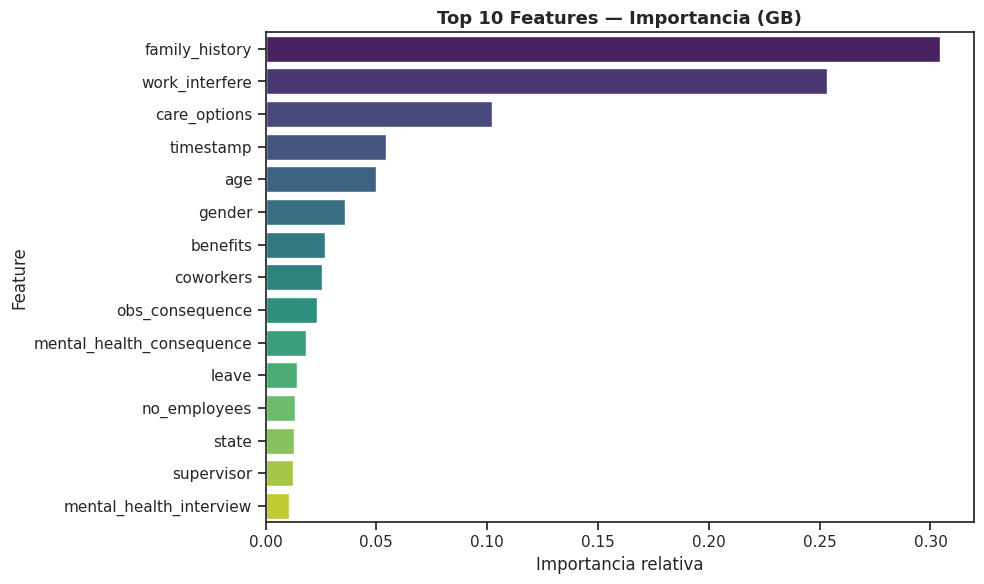

In [ ]:
rf_best = best_models['GB']
rf_best.fit(X_train_numeric, y_train)

feature_importance_df = pd.DataFrame({
    'Feature':    X_train_numeric.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 10 Features — Importance (GB)', fontsize=13, fontweight='bold')
plt.xlabel('Relative importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 18. ROC Curve of the Final Model

The ROC curve is generated for the model with the best F1-score, using the corresponding test data. It allows us to visualize how well the model distinguishes between the two classes (seeks treatment vs. does not seek treatment) — that is, the model's effectiveness.


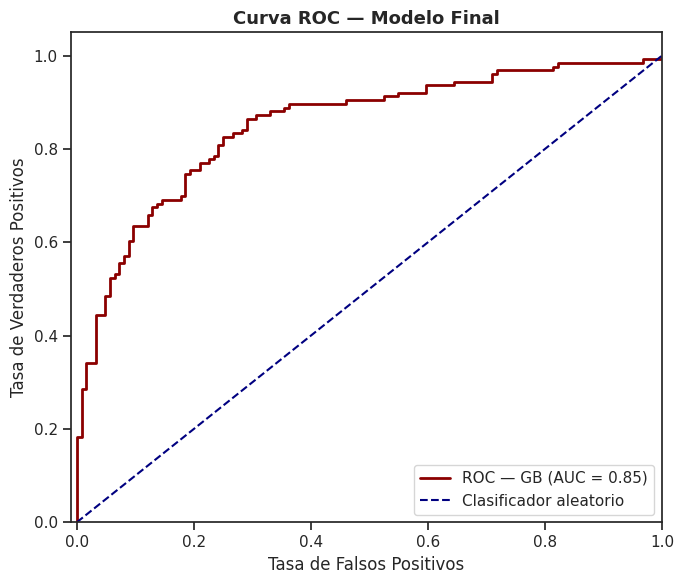

AUC del modelo final (GB): 0.8514


In [ ]:
y_score = final_model.predict_proba(X_test_final.drop(columns=['country', 'comments']))[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'ROC — {final_model_name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random classifier')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Model', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Final model AUC ({final_model_name}): {roc_auc:.4f}')


CV, data augmentation — TO INVESTIGATE
